## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [5]:
data = pd.read_csv('Telecom_Customer_Churn.csv')

In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
data.shape

(7043, 21)

In [8]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Transformation

In [10]:
# Dropping unnecessary columns (if applicable)
data.set_index('customerID', inplace=True)

# Converting 'TotalCharges' to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0).astype(int)

In [11]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


## Label Encoding

In [12]:
#transfomartion categorical to numerical
from sklearn.preprocessing import LabelEncoder

encode = data[['gender', 'Partner', 'Dependents',
         'PhoneService', 'MultipleLines', 'InternetService',
         'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'Churn']]

le = LabelEncoder()

for column in encode:
  data[column] = le.fit_transform(data[column])

In [13]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


## Build Random Forest

In [14]:
# random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# train random forest model
rf = RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42,)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

## Random Forest Model Evaluation

In [18]:
# Predict on training and testing data
train_preds = rf.predict(x_train)
test_preds = rf.predict(x_test)

In [19]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

In [20]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9986
Testing Accuracy: 0.7970



## Confusion Matrix

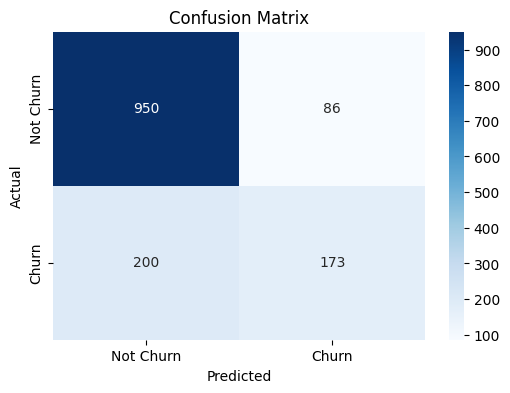

In [21]:
# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- True Negative (`TN`): Correctly predicted negative class (Actual = `Not Churn`, Predicted = `Not Churn`)
- False Positive (`FP`): Incorrectly predicted as positive (Actual = `Not Churn`, Predicted = `Churn`)
- False Negative (`FN`): Incorrectly predicted as negative (Actual = `Churn`, Predicted = `Not Churn`)
- True Positive (`TP`): Correctly predicted positive class (Actual = `Churn`, Predicted = `Churn`)

## Classification Report

In [22]:
# classification report
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_preds))

Classification Report (Testing Data):

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.46      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



## Summary:


1. **Overall Accuracy**:
  - The Random Forest model achieved an overall accuracy of 79%, meaning it correctly classified 79% of the samples in the test data.

2. **Class-Specific Performance:**

**Class 0 (Non-Churn):**

- `Precision`: 83% - When the model predicts a customer will not churn, it is correct 83% of the time.
- `Recall`: 92% - The model correctly identifies 92% of the actual non-churn customers.
- `F1-Score`: 87% - The balance between precision and recall is high for this class.

**Class 1 (Churn):**
- `Precision`: 67% - When the model predicts a customer will churn, it is correct 67% of the time.
- `Recall`: 47% - The model identifies only 47% of the actual churn cases.
- `F1-Score`: 55% - The performance on this class is relatively weaker compared to Class 0.

3. **Model Weakness:**
- The model struggles to correctly identify churners (Class 1) with a low recall of 47%. This means many churn cases are being missed, which is critical in customer churn analysis.


## Improvements:

**Feature Engineering:**

- Investigate if additional features can help distinguish churners more effectively.
- Perform `feature importance analysis` to identify and focus on the most informative features.

**Hyperparameter Tuning:**

- Adjust Random Forest parameters like `max_depth`, `min_samples_split`, and `class_weight` to improve the model's recall for churn cases.

**Consider Alternative Models:**

- Explore boosting methods (e.g., Gradient Boosting, XGBoost) as they often perform better on imbalanced datasets.

## Feature Importance : RFC

In [23]:
rf.feature_importances_

array([0.02944738, 0.02071119, 0.02420337, 0.02111963, 0.15587695,
       0.00543931, 0.02332566, 0.0263124 , 0.04351794, 0.02591364,
       0.02090778, 0.03881626, 0.01768532, 0.01853648, 0.08264612,
       0.02564275, 0.05230541, 0.19309497, 0.17449743])

In [24]:
feature_importance = pd.DataFrame({'Importance':rf.feature_importances_},index=X.columns).sort_values('Importance')

In [25]:
feature_importance

,Importance
PhoneService,0.005439
StreamingTV,0.017685
StreamingMovies,0.018536
SeniorCitizen,0.020711
DeviceProtection,0.020908
Dependents,0.021120
MultipleLines,0.023326
Partner,0.024203
PaperlessBilling,0.025643
OnlineBackup,0.025914


Text(0.5, 1.0, 'Feature Importance')

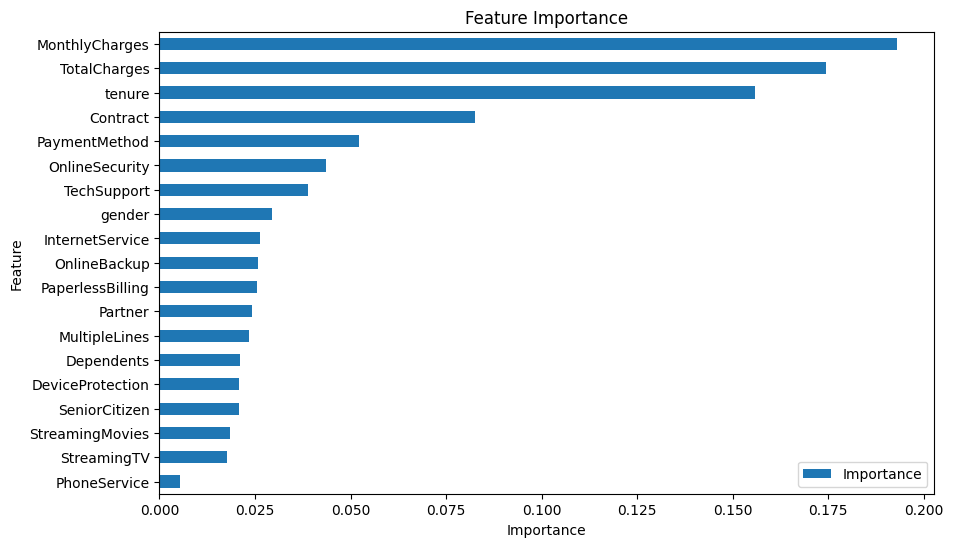

In [26]:
feature_importance.plot(y='Importance', kind='barh', figsize=(10, 6))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

In [29]:
feature_importance[feature_importance.Importance > 0.05]

,Importance
PaymentMethod,0.052305
Contract,0.082646
tenure,0.155877
TotalCharges,0.174497
MonthlyCharges,0.193095


In [30]:
to_keep = feature_importance[feature_importance.Importance > 0.05]
to_keep

,Importance
PaymentMethod,0.052305
Contract,0.082646
tenure,0.155877
TotalCharges,0.174497
MonthlyCharges,0.193095


In [31]:
X_rf = data[to_keep.index]
y = data['Churn']

In [32]:
X_rf

,PaymentMethod,Contract,tenure,TotalCharges,MonthlyCharges
customerID,,,,,
7590-VHVEG,2,0,1,29,29.85
5575-GNVDE,3,1,34,1889,56.95
3668-QPYBK,3,0,2,108,53.85
7795-CFOCW,0,1,45,1840,42.30
9237-HQITU,2,0,2,151,70.70
...,...,...,...,...,...
6840-RESVB,3,1,24,1990,84.80
2234-XADUH,1,1,72,7362,103.20
4801-JZAZL,2,0,11,346,29.60


In [33]:
y

customerID
7590-VHVEG    0
5575-GNVDE    0
3668-QPYBK    1
7795-CFOCW    0
9237-HQITU    1
             ..
6840-RESVB    0
2234-XADUH    0
4801-JZAZL    0
8361-LTMKD    1
3186-AJIEK    0
Name: Churn, Length: 7043, dtype: int64

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, random_state=42)

In [35]:
clf = RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42,)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [38]:
clf.score(X_train, y_train),clf.score(X_test, y_test)

(0.9941427050053249, 0.7714691270404542)

In [39]:
y_pred = clf.predict(X_test)
rfc_selected_features_accuracy = accuracy_score(y_test, y_pred)
print(f"RFC Selected Features Model Accuracy: {rfc_selected_features_accuracy:.4f}")

RFC Selected Features Model Accuracy: 0.7715


## LOFO : Leave One Feature Out

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Set the baseline accuracy from the full feature set model
base_accuracy = test_accuracy

feature_importance_lofo = {}
max_lofo_accuracy = base_accuracy  # Initialize with the full model accuracy

for feature in X.columns:
    # Remove one feature and train a new model
    X_train_reduced = X_train.drop(columns=[feature])
    X_test_reduced = X_test.drop(columns=[feature])
    temp_rf = RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42)
    temp_rf.fit(X_train_reduced, y_train)
    y_pred_reduced = temp_rf.predict(X_test_reduced)
    reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

    # Compute the performance drop
    performance_drop = base_accuracy - reduced_accuracy
    feature_importance_lofo[feature] = performance_drop

    # Track the best accuracy achieved by removing a feature
    if reduced_accuracy > max_lofo_accuracy:
        max_lofo_accuracy = reduced_accuracy

# Sort and display feature importance based on performance drop
sorted_importance_lofo = sorted(feature_importance_lofo.items(), key=lambda x: x[1], reverse=False)

print("\nFeature Importance (LOFO - Performance Drop relative to full model accuracy):")
for feature, drop in sorted_importance_lofo:
    print(f"{feature}: Performance Drop = {drop:.4f}")

print(f"\nLOFO Derived Best Accuracy (by removing one feature): {max_lofo_accuracy:.4f}")



Feature Importance (LOFO - Performance Drop relative to full model accuracy):
Dependents: Performance Drop = -0.0035
OnlineSecurity: Performance Drop = -0.0028
gender: Performance Drop = -0.0021
PaperlessBilling: Performance Drop = -0.0007
PaymentMethod: Performance Drop = -0.0007
TechSupport: Performance Drop = 0.0014
TotalCharges: Performance Drop = 0.0014
StreamingMovies: Performance Drop = 0.0021
Partner: Performance Drop = 0.0035
PhoneService: Performance Drop = 0.0035
OnlineBackup: Performance Drop = 0.0035
DeviceProtection: Performance Drop = 0.0035
InternetService: Performance Drop = 0.0043
SeniorCitizen: Performance Drop = 0.0050
tenure: Performance Drop = 0.0050
Contract: Performance Drop = 0.0050
StreamingTV: Performance Drop = 0.0064
MultipleLines: Performance Drop = 0.0078
MonthlyCharges: Performance Drop = 0.0078

LOFO Derived Best Accuracy (by removing one feature): 0.8006


## Comparison

In [42]:
accuracy_scores = {
    'Base Model Accuracy': test_accuracy,
    'RFC Selected Features Model Accuracy': rfc_selected_features_accuracy,
    'LOFO Derived Best Accuracy': max_lofo_accuracy
}

print("Collected Accuracy Scores:")
for model, score in accuracy_scores.items():
    print(f"- {model}: {score:.4f}")

Collected Accuracy Scores:
- Base Model Accuracy: 0.7970
- RFC Selected Features Model Accuracy: 0.7715
- LOFO Derived Best Accuracy: 0.8006


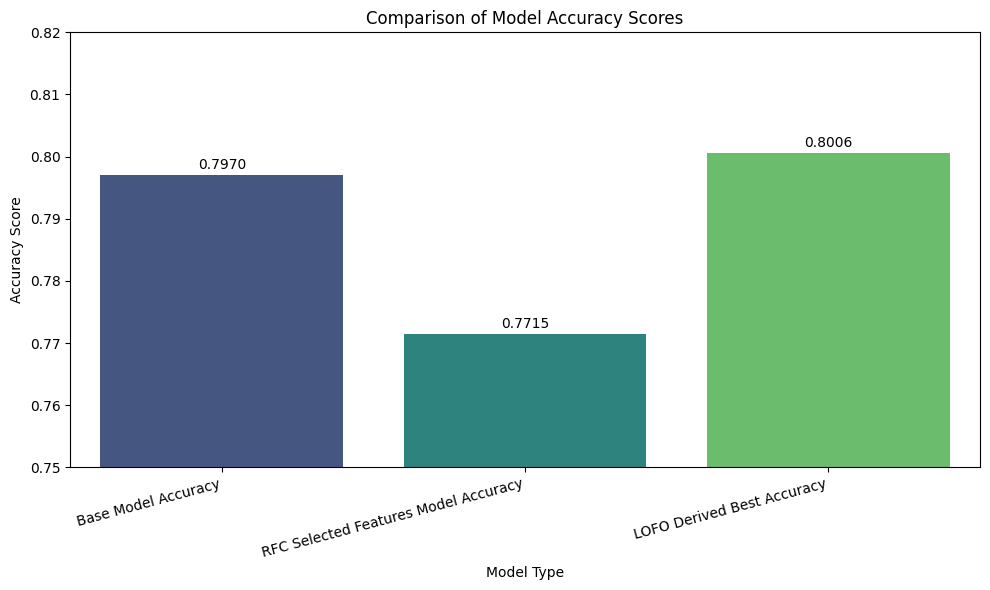

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the dictionary to a pandas Series for plotting
accuracy_series = pd.Series(accuracy_scores)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracy_series.index, y=accuracy_series.values, hue=accuracy_series.index, palette='viridis', legend=False)

# Add labels and title
plt.xlabel('Model Type')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracy Scores')
plt.ylim(0.75, 0.82) # Set y-axis limits for better comparison of small differences

# Add accuracy values on top of the bars
for index, value in enumerate(accuracy_series.values):
    plt.text(index, value + 0.001, f'{value:.4f}', color='black', ha='center')

plt.xticks(rotation=15, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

LOFO slightly outperformed the base model, showing that evaluating features based on performance impact can improve accuracy.

The RFC-selected feature model performed worse than both the base and LOFO models, showing that selecting features using a fixed importance threshold can remove features that are individually low-ranked but still valuable when combined with others.

Overall, LOFO proved to be the most effective feature selection method in this comparison.